# BDD100K EDA with LanceDB — Larger-Than-Memory Dataset Exploration

This notebook shows how to explore a 25k-frame driving dataset stored in LanceDB
**without ever loading the full dataset into memory**.

Key principles used throughout:
- `tbl.count_rows(filter=...)` for distributions — reads metadata only, O(1)
- `tbl.search().where(...).select([cols]).limit(n)` for bounded scans
- Aggregations pushed into SQL filters, not Python loops over full data
- Images decoded only for small previews (≤ 8 frames at a time)

**Never used**: `tbl.to_pandas()`, `tbl.to_arrow()`, or `tbl.to_lance()` without a `limit()`.

In [7]:
import io
import sys
from pathlib import Path
from collections import Counter

import lancedb
import pyarrow as pa
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

# Add src to path so spec_queries / manage_views are importable
sys.path.insert(0, str(Path("..").resolve() / "src"))

DB_PATH = "../data/bdd100k/lancedb"
TABLE   = "bdd100k"

db  = lancedb.connect(DB_PATH)
tbl = db.open_table(TABLE)

print(f"Connected — table '{TABLE}'")

Connected — table 'bdd100k'


## 1. Table Overview
Schema and size — no data loaded.

In [8]:
# count_rows() reads Lance metadata — does not scan image data
total = tbl.count_rows()
print(f"Total rows : {total:,}")
print(f"Version    : {tbl.version}")
print(f"Columns    : {len(tbl.schema)}\n")

# Schema — just metadata, no data loaded
for field in tbl.schema:
    print(f"  {field.name:<35} {field.type}")

Total rows : 82,000
Version    : 194
Columns    : 25

  image_id                            string
  split                               string
  image_bytes                         large_binary
  width                               int32
  height                              int32
  weather                             string
  scene                               string
  timeofday                           string
  timestamp                           int64
  ann_categories                      list<item: string>
  ann_bboxes                          list<item: list<item: float>>
  ann_occluded                        list<item: bool>
  ann_truncated                       list<item: bool>
  ann_traffic_light_colors            list<item: string>
  num_annotations                     int32
  has_person                          bool
  has_rider                           bool
  white_balance                       float
  scene_description                   string
  scene_has_crossroad      

## 2. Frame Distributions

Use `count_rows(filter=...)` for each category value — no full scan, no data in memory.

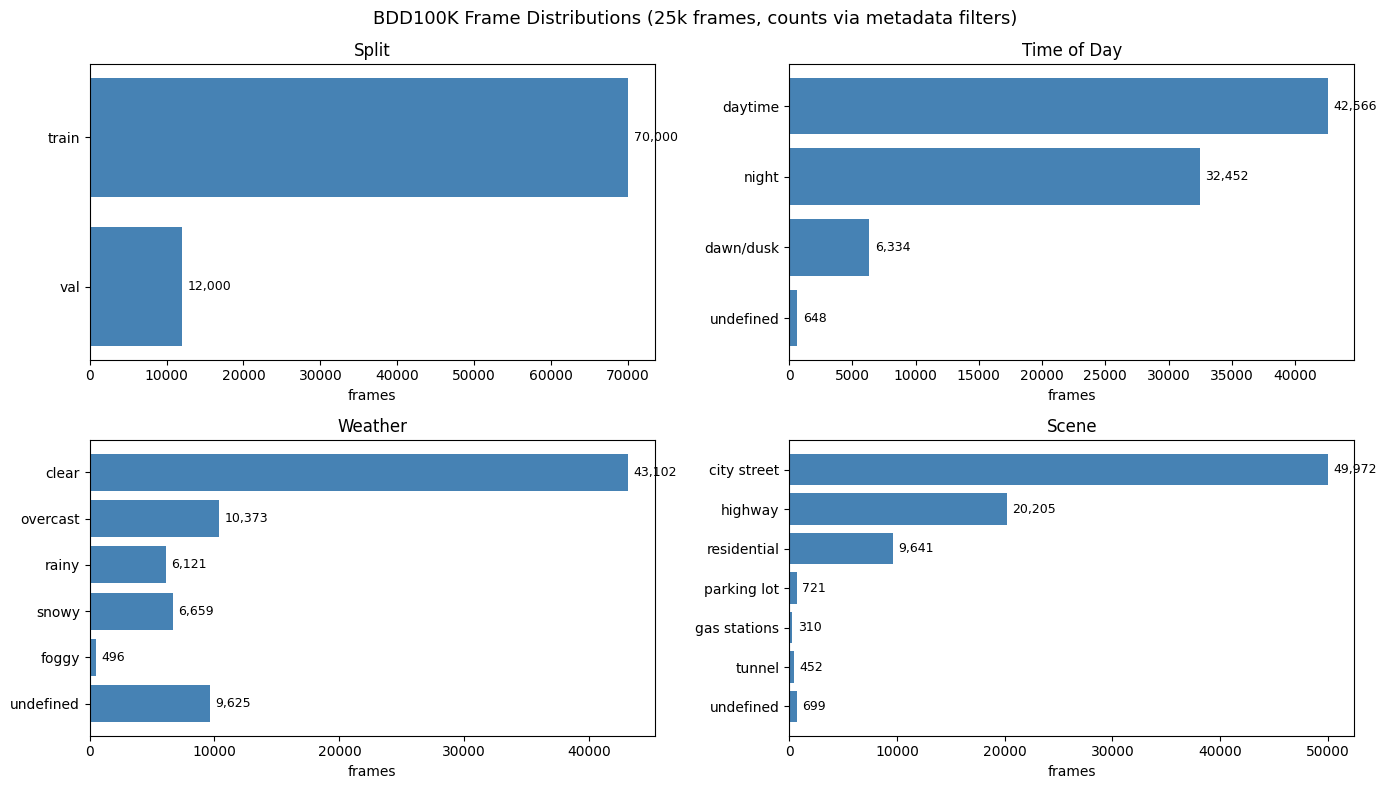

In [9]:
def count_distribution(tbl, column, values):
    """Count rows per value using metadata-only filter queries."""
    return {v: tbl.count_rows(filter=f"{column} = '{v}'") for v in values}

splits     = count_distribution(tbl, "split",     ["train", "val"])
timeofday  = count_distribution(tbl, "timeofday", ["daytime", "night", "dawn/dusk", "undefined"])
weather    = count_distribution(tbl, "weather",   ["clear", "overcast", "rainy", "snowy", "foggy", "undefined"])
scenes     = count_distribution(tbl, "scene",     ["city street", "highway", "residential",
                                                    "parking lot", "gas stations", "tunnel", "undefined"])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("BDD100K Frame Distributions (25k frames, counts via metadata filters)", fontsize=13)

for ax, (title, dist) in zip(axes.flat, [
    ("Split", splits), ("Time of Day", timeofday),
    ("Weather", weather), ("Scene", scenes)
]):
    labels = list(dist.keys())
    values = list(dist.values())
    bars = ax.barh(labels, values, color="steelblue")
    ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("frames")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Annotation Category Distribution

`ann_categories` is a list column — we sample a bounded slice (5k frames) and unpack in Python.
We never scan the full table.

Sampled 5,000 frames  |  92,433 total annotations

category                 boxes   % of sample
--------------------------------------------
  car                   51,398       1028.0%
  traffic sign          17,195        343.9%
  traffic light         13,370        267.4%
  person                 6,389        127.8%
  truck                  2,176         43.5%
  bus                      836         16.7%
  bike                     527         10.5%
  rider                    321          6.4%
  motor                    209          4.2%
  train                     12          0.2%


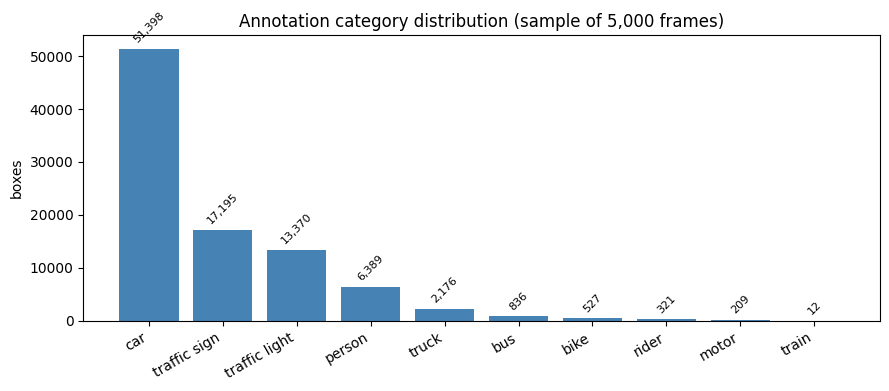

In [10]:
SAMPLE_N = 5_000  # bounded scan — never load the full table

# Select only the lightweight columns needed; exclude image_bytes entirely
sample = (
    tbl.search()
       .select(["ann_categories", "num_annotations", "split"])
       .limit(SAMPLE_N)
       .to_pandas()
)

cat_counter = Counter()
for cats in sample["ann_categories"]:
    if cats is not None:
        cat_counter.update(list(cats))

print(f"Sampled {len(sample):,} frames  |  {sample['num_annotations'].sum():,} total annotations\n")
print(f"{'category':<20}  {'boxes':>8}  {'% of sample':>12}")
print("-" * 44)
for cat, n in cat_counter.most_common():
    pct = n / len(sample) * 100
    print(f"  {cat:<18}  {n:>8,}  {pct:>11.1f}%")

fig, ax = plt.subplots(figsize=(9, 4))
cats_sorted = dict(sorted(cat_counter.items(), key=lambda x: -x[1]))
bars = ax.bar(cats_sorted.keys(), cats_sorted.values(), color="steelblue")
ax.bar_label(bars, fmt="{:,.0f}", rotation=45, fontsize=8, padding=3)
ax.set_title(f"Annotation category distribution (sample of {SAMPLE_N:,} frames)")
ax.set_ylabel("boxes")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4. Geneva UDF Column Distributions

These columns were backfilled by Geneva — `has_person`, `has_rider`, `vehicle_label`.
All counts via `count_rows(filter=...)`, no data loaded.

Annotation presence flags:
  has_person     : 25,830  (31.5%)
  has_rider      :  4,626  (5.6%)
  night+person   :  6,564  (8.0%)
  night+rider    :    979  (1.2%)

person_bbox_area_pct buckets (frames where a person is annotated):
    0% –   1%  : 21,464
    1% –   5%  :  3,576
    5% –  15%  :    699
   15% –  30%  :     77
   30% – 100%  :     14


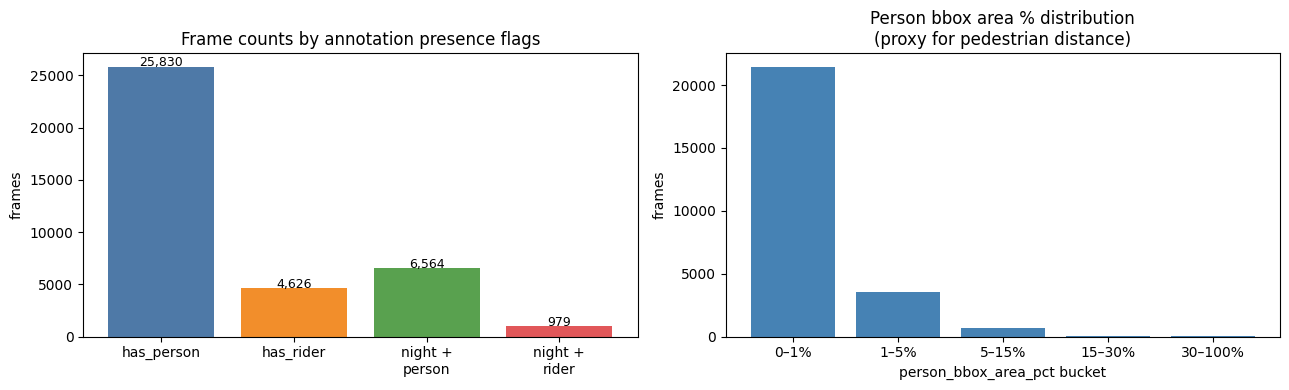

In [11]:
total = tbl.count_rows()

has_person = tbl.count_rows(filter="has_person = true")
has_rider  = tbl.count_rows(filter="has_rider = true")

night_person = tbl.count_rows(filter="timeofday = 'night' AND has_person = true")
night_rider  = tbl.count_rows(filter="timeofday = 'night' AND has_rider = true")

print("Annotation presence flags:")
print(f"  has_person     : {has_person:>6,}  ({has_person/total*100:.1f}%)")
print(f"  has_rider      : {has_rider:>6,}  ({has_rider/total*100:.1f}%)")
print(f"  night+person   : {night_person:>6,}  ({night_person/total*100:.1f}%)")
print(f"  night+rider    : {night_rider:>6,}  ({night_rider/total*100:.1f}%)")

# person_bbox_area_pct distribution — counts across threshold buckets
print("\nperson_bbox_area_pct buckets (frames where a person is annotated):")
for lo, hi in [(0, 1), (1, 5), (5, 15), (15, 30), (30, 100)]:
    n = tbl.count_rows(filter=f"has_person = true AND person_bbox_area_pct >= {lo} AND person_bbox_area_pct < {hi}")
    print(f"  {lo:3d}% – {hi:3d}%  : {n:>6,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

flags = {
    "has_person": has_person,
    "has_rider": has_rider,
    "night +\nperson": night_person,
    "night +\nrider": night_rider,
}
axes[0].bar(flags.keys(), flags.values(), color=["#4e79a7", "#f28e2b", "#59a14f", "#e15759"])
axes[0].set_title("Frame counts by annotation presence flags")
axes[0].set_ylabel("frames")
for i, v in enumerate(flags.values()):
    axes[0].text(i, v + 20, f"{v:,}", ha="center", fontsize=9)

buckets = {"0–1%": 0, "1–5%": 0, "5–15%": 0, "15–30%": 0, "30–100%": 0}
for label, (lo, hi) in zip(buckets, [(0,1),(1,5),(5,15),(15,30),(30,100)]):
    buckets[label] = tbl.count_rows(
        filter=f"has_person = true AND person_bbox_area_pct >= {lo} AND person_bbox_area_pct < {hi}"
    )
axes[1].bar(buckets.keys(), buckets.values(), color="steelblue")
axes[1].set_title("Person bbox area % distribution\n(proxy for pedestrian distance)")
axes[1].set_ylabel("frames")
axes[1].set_xlabel("person_bbox_area_pct bucket")

plt.tight_layout()
plt.show()

## 5. Curation Spec Counts

How many frames match each curated training spec? All counts, no data loaded.

In [12]:
from object_detection.spec_queries import SPEC_FILTERS

print(f"{'spec':<25}  {'train':>8}  {'val':>8}  {'total':>8}  filter")
print("-" * 95)

for spec, filter_template in SPEC_FILTERS.items():
    # Use default thresholds where needed
    try:
        sql = filter_template.format(bbox_pct=5.0, min_confidence=0.5)
    except KeyError:
        sql = filter_template

    n_train = tbl.count_rows(filter=f"split = 'train' AND ({sql})")
    n_val   = tbl.count_rows(filter=f"split = 'val'   AND ({sql})")
    n_total = n_train + n_val
    print(f"  {spec:<23}  {n_train:>8,}  {n_val:>8,}  {n_total:>8,}  {sql}")

ModuleNotFoundError: No module named 'object_detection'

## 6. Preview: Sample Frames

Fetch 8 frames using `.select(["image_bytes", ...]).limit(8)` — images decoded in Python,
only those 8 JPEGs touch memory.

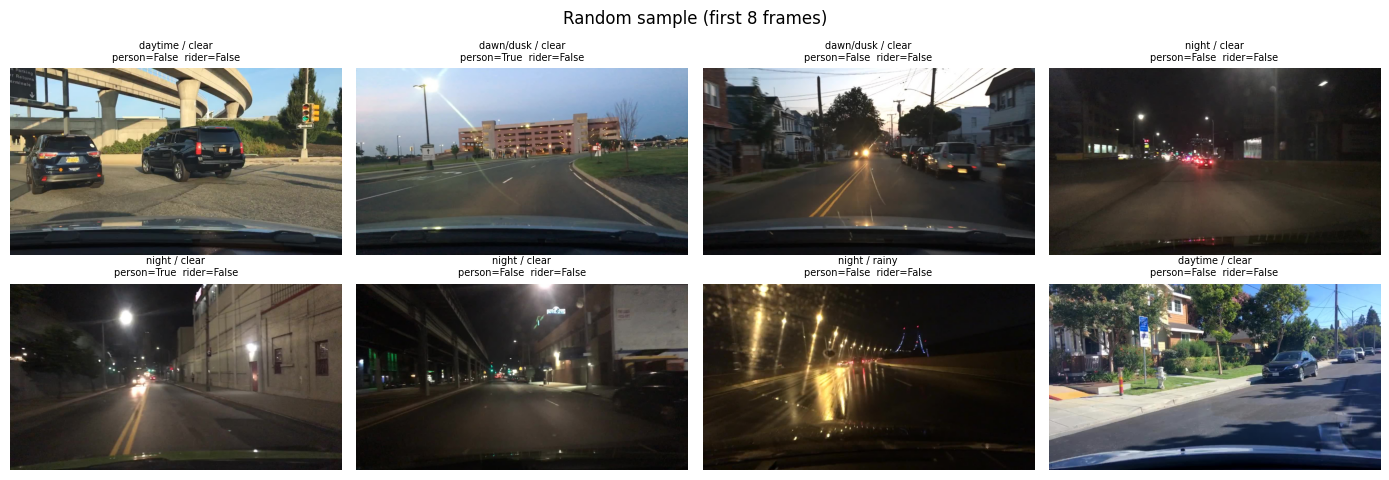

In [13]:
def preview_frames(tbl, where=None, n=8, title="Sample frames"):
    """Show a grid of n frames. Fetches only image_bytes + metadata for those n rows."""
    q = tbl.search().select(["image_bytes", "image_id", "timeofday", "weather",
                              "has_person", "has_rider"])
    if where:
        q = q.where(where)
    rows = q.limit(n).to_pandas()

    cols = 4
    rows_n = (len(rows) + cols - 1) // cols
    fig, axes = plt.subplots(rows_n, cols, figsize=(cols * 3.5, rows_n * 2.5))
    fig.suptitle(title, fontsize=12)
    axes = axes.flat if hasattr(axes, "flat") else [axes]

    for ax, (_, row) in zip(axes, rows.iterrows()):
        img_bytes = bytes(row["image_bytes"])
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"{row['timeofday']} / {row['weather']}\n"
            f"person={row['has_person']}  rider={row['has_rider']}",
            fontsize=7
        )
        ax.axis("off")

    for ax in list(axes)[len(rows):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# General sample
preview_frames(tbl, title="Random sample (first 8 frames)")

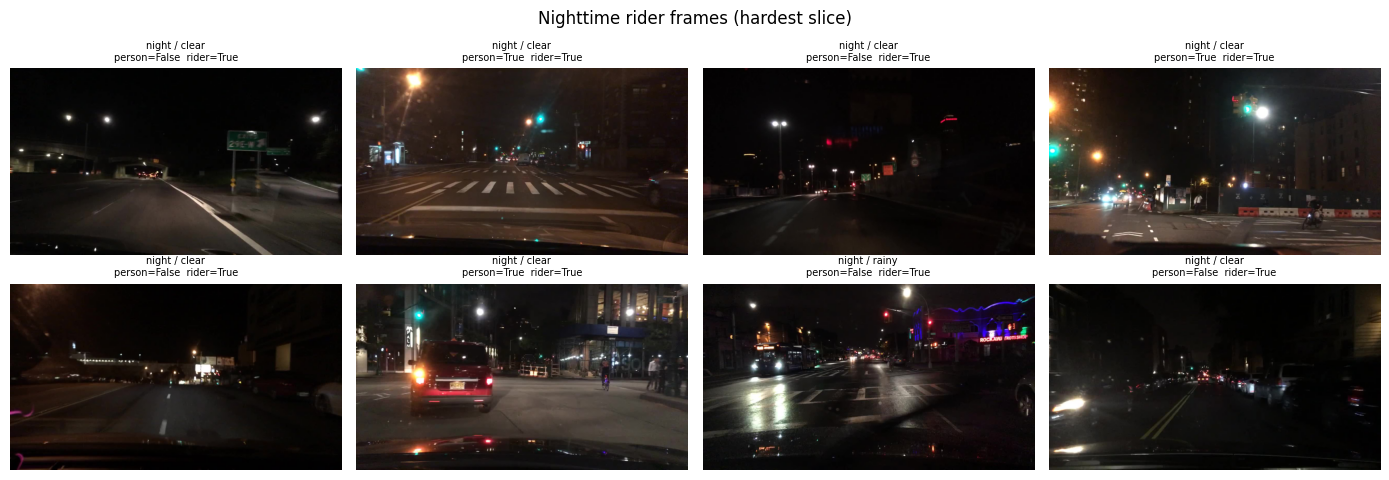

In [14]:
# Preview nighttime frames with riders — the hardest curated slice
preview_frames(
    tbl,
    where="timeofday = 'night' AND has_rider = true",
    title="Nighttime rider frames (hardest slice)"
)

## 7. Full-Text Search on Scene Descriptions

Geneva's `scene_description` UDF generates text like `"night rainy scene on a city street"`.
Build an FTS index once, then search without loading any frame data.

## 8. CLIP Vector Search — Text-to-Image and Image-to-Image

`clip_embedding` is a 512-d L2-normalised vector backfilled by a Geneva GPU UDF
using OpenAI's ViT-B/32. Because CLIP's image and text encoders share the same
embedding space, you can search the table with a natural-language query — no SQL
predicate, no annotation required.

Three use cases shown here:
1. **Text → Image**: retrieve frames matching a natural-language description
2. **Image → Image**: find visually similar frames to a query frame
3. **Hybrid**: CLIP retrieval scoped to a SQL pre-filter (e.g. nighttime only)

Requires: `pip install open-clip-torch`

In [15]:
import torch
import open_clip

# Load CLIP text encoder — CPU is fine for encoding queries, only the backfill UDF needs GPU
_clip_model, _, _clip_preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
_clip_model.eval()
_tokenizer = open_clip.get_tokenizer("ViT-B-32")


def encode_text(query: str) -> list[float]:
    """Encode a text query into the CLIP embedding space."""
    tokens = _tokenizer([query])
    with torch.no_grad():
        vec = _clip_model.encode_text(tokens)
        vec = vec / vec.norm(dim=-1, keepdim=True)
    return vec[0].float().tolist()


def encode_image_bytes(raw: bytes) -> list[float]:
    """Encode a raw JPEG into the CLIP embedding space (for image-to-image search)."""
    img = Image.open(io.BytesIO(raw)).convert("RGB")
    tensor = _clip_preprocess(img).unsqueeze(0)
    with torch.no_grad():
        vec = _clip_model.encode_image(tensor)
        vec = vec / vec.norm(dim=-1, keepdim=True)
    return vec[0].float().tolist()


def clip_search(query_vec, where=None, limit=8):
    """
    Vector search on clip_embedding.

    query_vec : 512-d list from encode_text() or encode_image_bytes()
    where     : optional SQL pre-filter (applied before vector scoring)
    """
    q = tbl.search(query_vec, vector_column_name="clip_embedding").metric("cosine")
    if where:
        q = q.where(where, prefilter=True)
    cols = ["image_bytes", "image_id", "timeofday", "weather", "has_person", "has_rider", "_distance"]
    return q.select(cols).limit(limit).to_pandas()


def show_clip_results(df, title="CLIP results"):
    n = len(df)
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    fig.suptitle(title, fontsize=12)
    for i, (ax, (_, row)) in enumerate(zip(axes.flat, df.iterrows())):
        img = Image.open(io.BytesIO(bytes(row["image_bytes"]))).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"{row['timeofday']} / {row['weather']}\n"
            f"person={row['has_person']}  rider={row['has_rider']}\n"
            f"dist={row['_distance']:.3f}",
            fontsize=7,
        )
        ax.axis("off")
    for ax in list(axes.flat)[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


print("CLIP model loaded — ViT-B/32 (OpenAI pretrained)")

/home/shadeform/.venv/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP model loaded — ViT-B/32 (OpenAI pretrained)


### 8a. Text → Image Search

Encode a natural-language description with CLIP's text encoder and search the `clip_embedding` index.
No SQL predicate — CLIP finds frames that match the scene semantically.

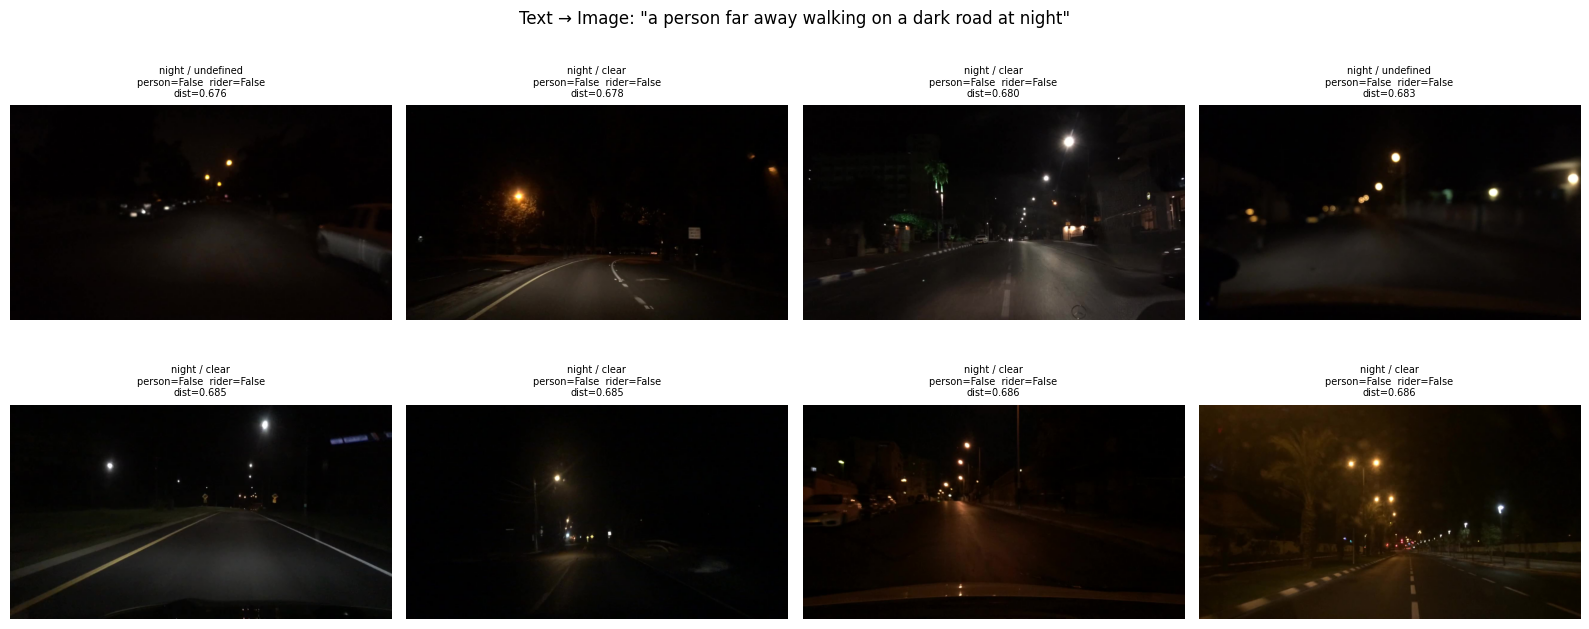

In [16]:
# Query 1: distant pedestrian on a dark highway — one of the three failure modes
results = clip_search(encode_text("a person far away walking on a dark road at night"))
show_clip_results(results, title='Text → Image: "a person far away walking on a dark road at night"')

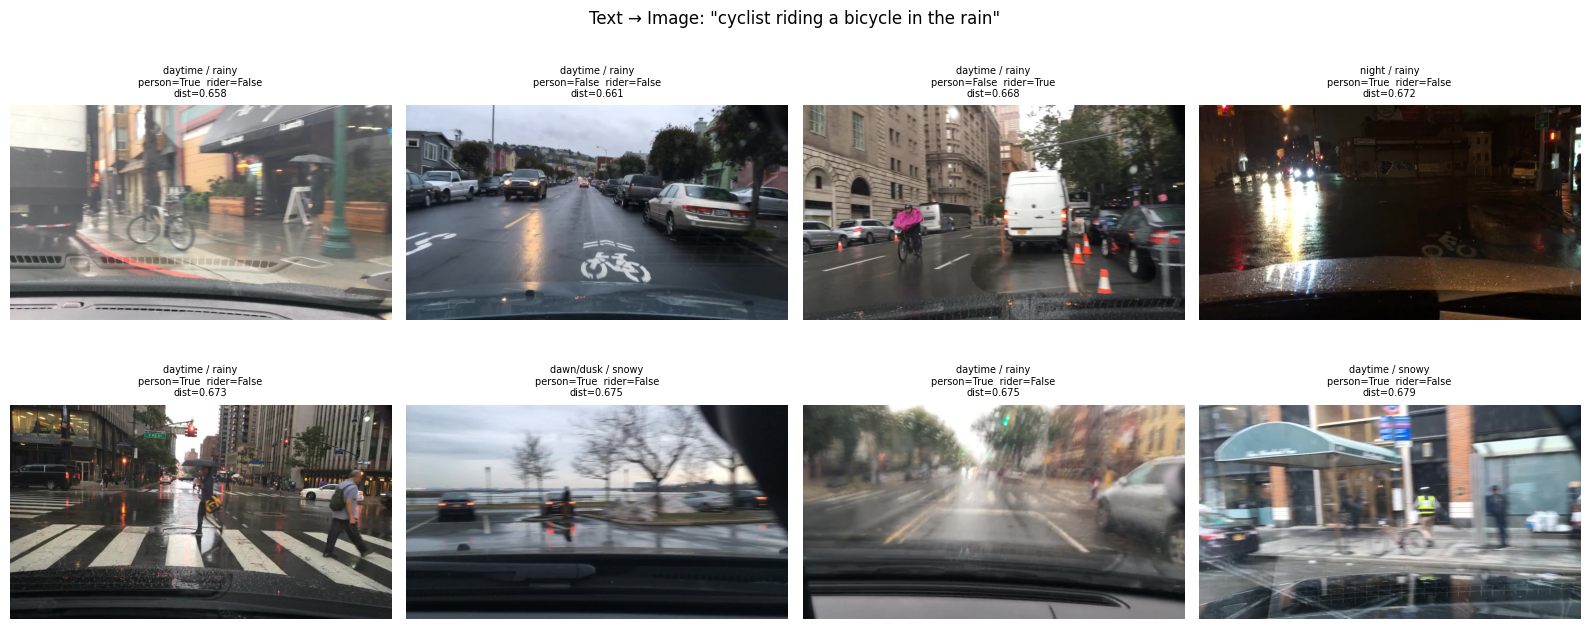

In [17]:
# Query 2: cyclist in rain — another of the three failure modes
results = clip_search(encode_text("cyclist riding a bicycle in the rain"))
show_clip_results(results, title='Text → Image: "cyclist riding a bicycle in the rain"')

### 8b. Image → Image Search

Pick a query frame from the curated rider split and find visually similar frames across the
full 100k table. Useful for finding cross-split near-duplicates or similar scenarios that
the SQL annotations don't directly surface.

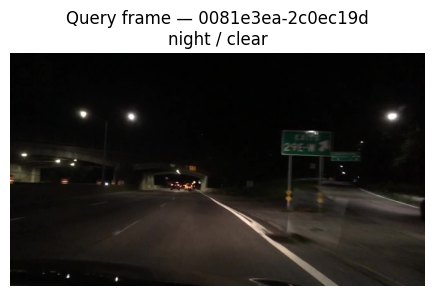

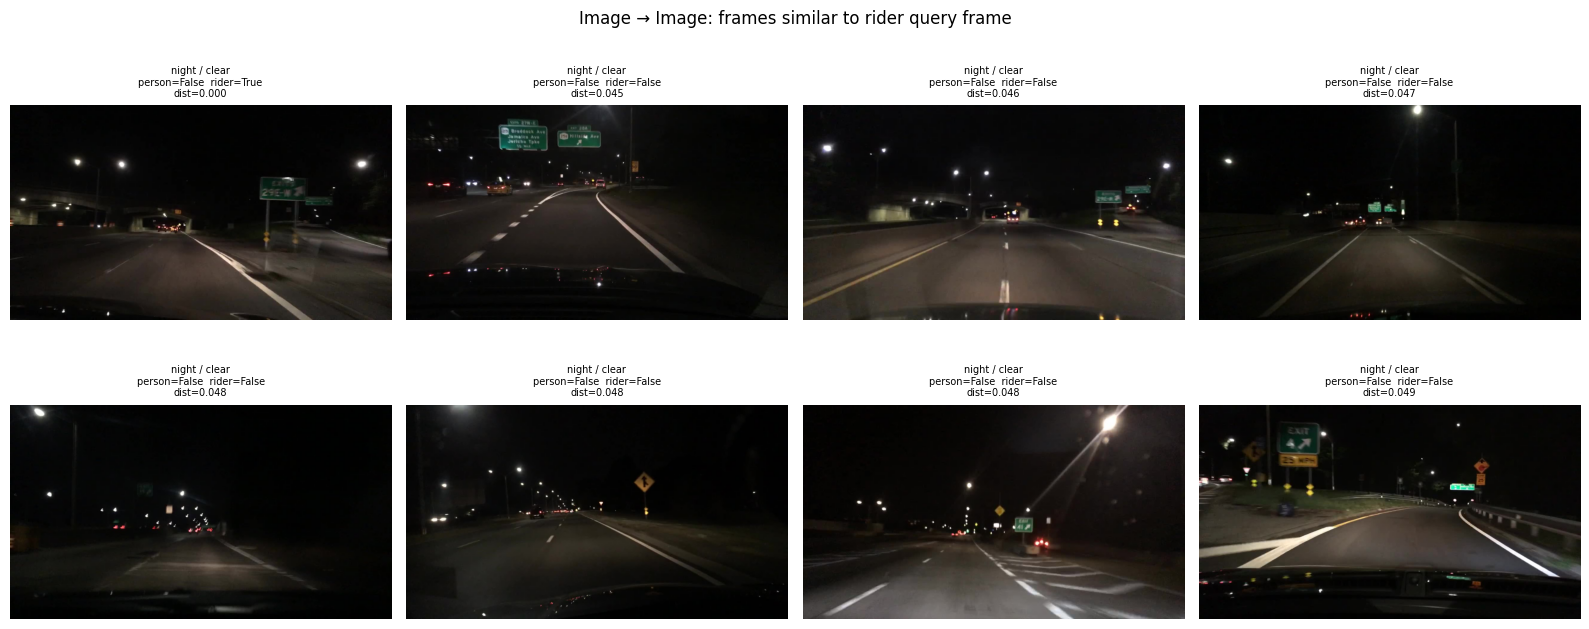

In [18]:
# Fetch one query frame from the rider split (has_rider=true, nighttime)
query_row = (
    tbl.search()
    .where("has_rider = true AND timeofday = 'night'")
    .select(["image_bytes", "image_id", "timeofday", "weather"])
    .limit(1)
    .to_pandas()
    .iloc[0]
)

query_img_bytes = bytes(query_row["image_bytes"])

# Show the query frame
fig, ax = plt.subplots(figsize=(5, 3))
ax.imshow(Image.open(io.BytesIO(query_img_bytes)))
ax.set_title(f"Query frame — {query_row['image_id']}\n{query_row['timeofday']} / {query_row['weather']}")
ax.axis("off")
plt.tight_layout()
plt.show()

# Encode query frame and search
query_vec = encode_image_bytes(query_img_bytes)
results = clip_search(query_vec, limit=8)
show_clip_results(results, title=f"Image → Image: frames similar to rider query frame")

### 8c. CLIP + SQL Pre-filter

Scope vector search to a SQL-filtered subset. Here: find frames visually similar to
"pedestrian crossing at an intersection" but restrict to nighttime only.
Neither SQL alone (no visual signal) nor CLIP alone (no metadata constraint) can do this.

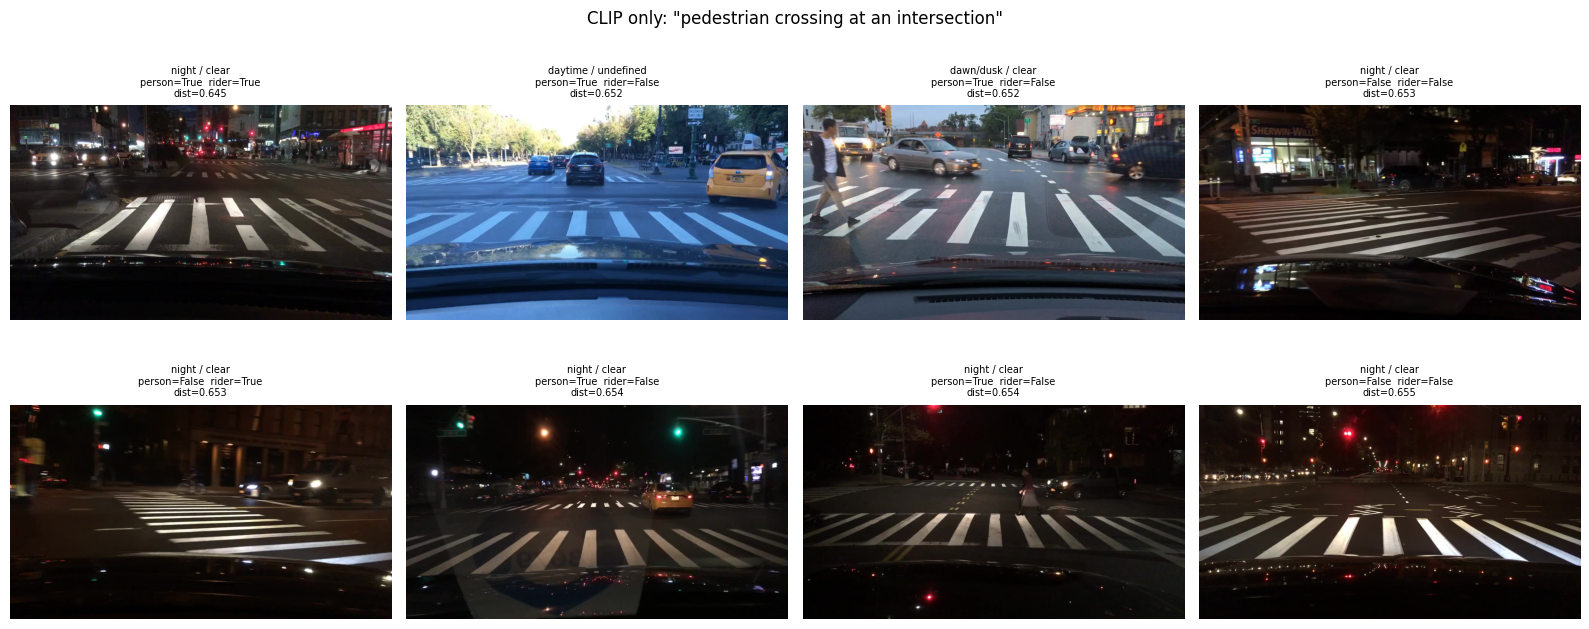

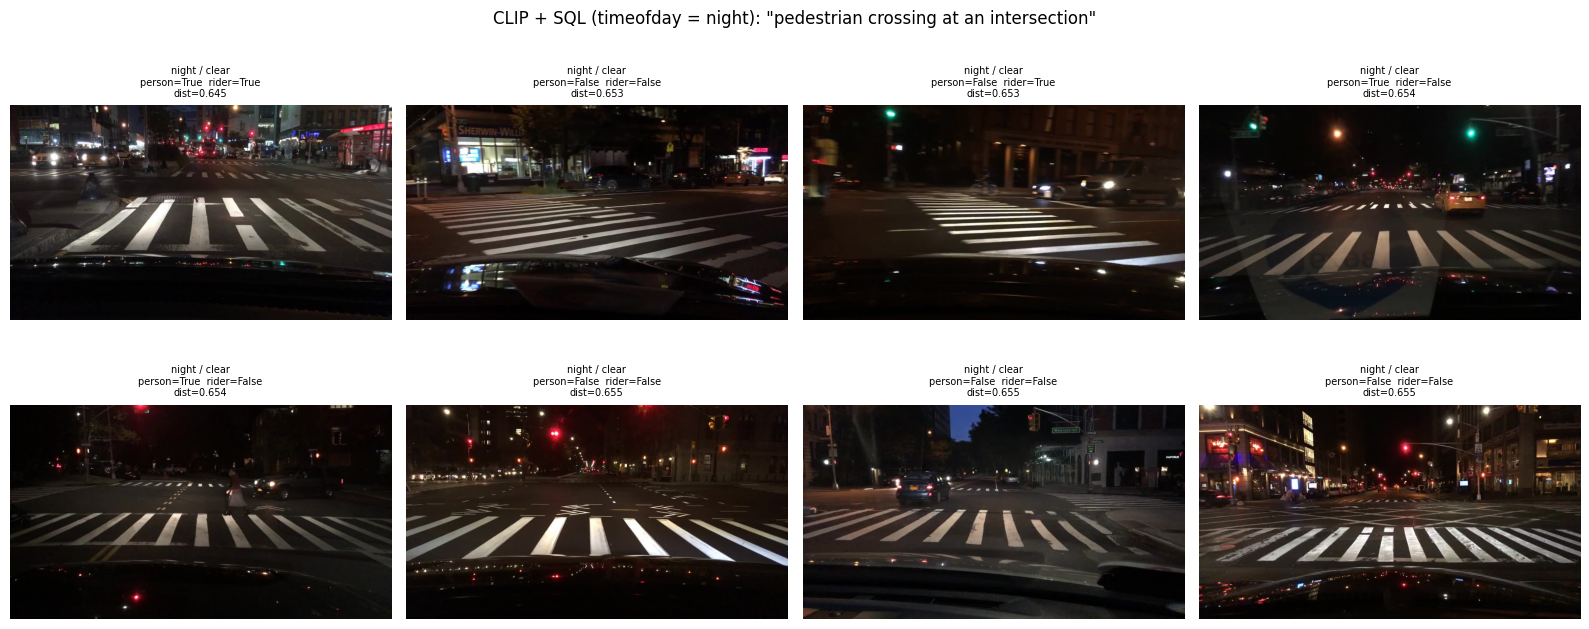

Without filter : 8 results
Nighttime only : 8 results

Timeofday distribution without filter:
timeofday
night        6
daytime      1
dawn/dusk    1

Timeofday distribution with filter:
timeofday
night    8


In [19]:
query = "pedestrian crossing at an intersection"
query_vec = encode_text(query)

# Without SQL filter: all times of day
all_results = clip_search(query_vec, limit=8)
show_clip_results(all_results, title=f'CLIP only: "{query}"')

# With SQL pre-filter: nighttime frames only
night_results = clip_search(query_vec, where="timeofday = 'night'", limit=8)
show_clip_results(night_results, title=f'CLIP + SQL (timeofday = night): "{query}"')

print(f"Without filter : {len(all_results)} results")
print(f"Nighttime only : {len(night_results)} results")
print(f"\nTimeofday distribution without filter:")
print(all_results["timeofday"].value_counts().to_string())
print(f"\nTimeofday distribution with filter:")
print(night_results["timeofday"].value_counts().to_string())

### 8d. Discovery — Unannotated Edge Cases

Find frames that CLIP thinks look like riders but are **not** annotated as riders
(`has_rider = false`). These are candidates for missing annotations or true near-misses —
exactly the kind of edge case that's hard to find with SQL alone.

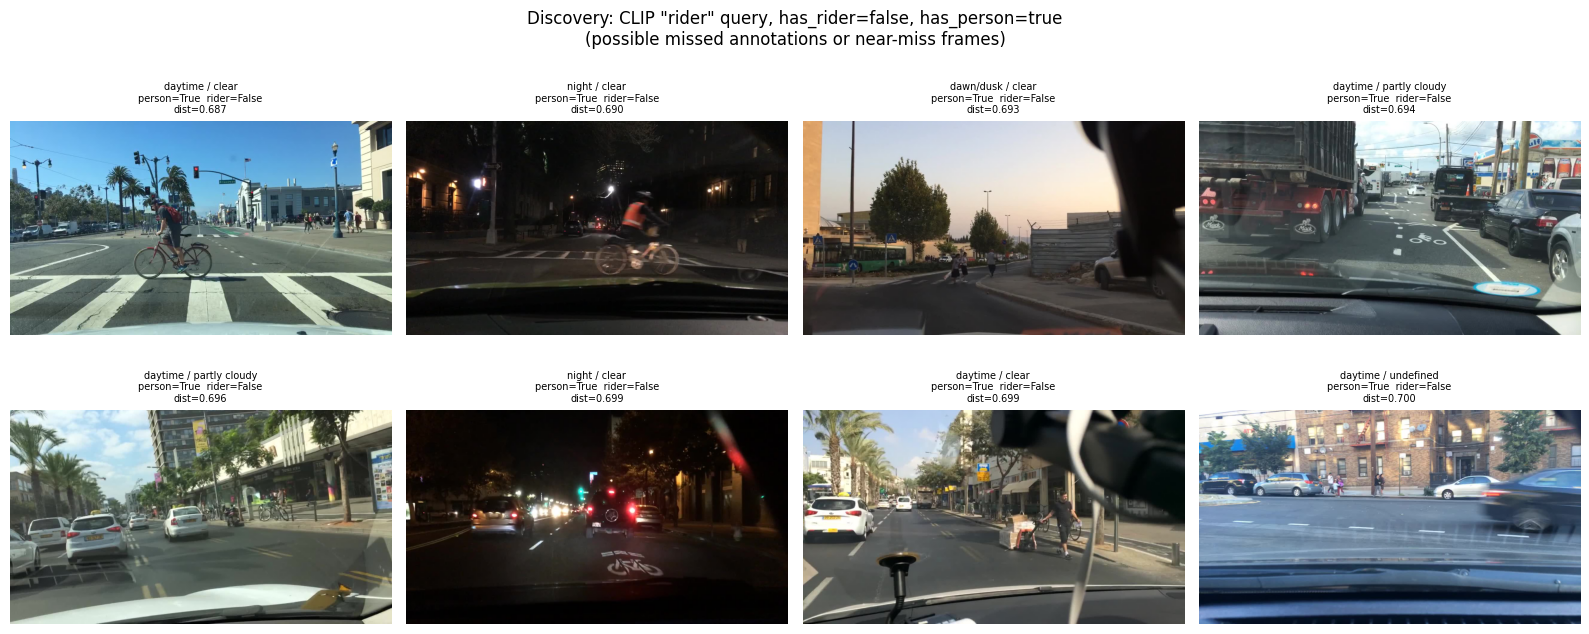

Annotated rider frames in table : 4,626
Top-50 CLIP hits that ARE annotated riders: 42
Top-50 CLIP hits that are NOT annotated riders: 8


In [20]:
query_vec = encode_text("person riding a bicycle or motorcycle on the road")

# Semantically: looks like a rider — but annotation says no rider present
edge_cases = clip_search(
    query_vec,
    where="has_rider = false AND has_person = true",
    limit=8,
)
show_clip_results(
    edge_cases,
    title='Discovery: CLIP "rider" query, has_rider=false, has_person=true\n(possible missed annotations or near-miss frames)',
)

n_total_riders    = tbl.count_rows(filter="has_rider = true")
n_annotated       = len(clip_search(encode_text("person riding a bicycle or motorcycle"), limit=50)
                         .query("has_rider == True"))
print(f"Annotated rider frames in table : {n_total_riders:,}")
print(f"Top-50 CLIP hits that ARE annotated riders: {n_annotated}")
print(f"Top-50 CLIP hits that are NOT annotated riders: {50 - n_annotated}")

## 8. Iterating on Curation Thresholds

The power of LanceDB: instantly test different filter thresholds without re-exporting data.
All just `count_rows()` calls.

In [23]:
# How does nighttime+rider count change across weather conditions?
print("Nighttime rider frames by weather:\n")
for w in ["clear", "overcast", "rainy", "snowy", "foggy"]:
    n = tbl.count_rows(filter=f"timeofday = 'night' AND has_rider = true AND weather = '{w}'")
    bar = "█" * (n // 2)
    print(f"  {w:<12}  {n:>4}  {bar}")

print()

# How does distant-person count change across bbox_pct thresholds?
# Useful for deciding the curation cutoff before materialising the view.
print("Distant person training frames by person_bbox_area_pct threshold:\n")
for pct in [1, 5, 10, 15, 20, 30]:
    n = tbl.count_rows(
        filter=f"split = 'train' AND has_person = true AND person_bbox_area_pct < {pct}"
    )
    print(f"  bbox_pct < {pct:2d}%  →  {n:>6,} frames")

Nighttime rider frames by weather:

  clear          734  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  overcast        26  █████████████
  rainy           85  ██████████████████████████████████████████
  snowy           77  ██████████████████████████████████████
  foggy           28  ██████████████

Distant person training frames by person_bbox_area_pct threshold:

  bbox_pct <  1%  →  18,304 frames
  bbox_pct <  5%  →  21,419 frames
  bbox_pct < 10%  →  21,910 frames
  bbox_pct < 15%  →  22,024 frames
  bbox_pct < 20%  →  22,067 frames
  bbox_pct < 30%  →  22,092 frames
